# **Crop Recommendation (Model Training)**
#### **Objective** : To train a Machine learning model to predict crop labels based on given features or variables.
#### **Problem Type** : Multiclass Classification (predict crop to grow based on given features)
#### The dataset consists of about 2200 samples and 7 Independent features to predict 22 different classes of crops.
#### **Dataset Link** - https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset

## **Exploratory Data Analysis**

In [ ]:
# Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [164]:
# Loading the downloaded dataset
path = r"Crop_recommendation.csv"
df = pd.read_csv(path)
df.sample(15)

,N,P,K,temperature,humidity,ph,rainfall,label
555,30,41,15,24.832066,44.170850,5.885097,52.081089,mothbeans
596,22,51,16,27.965837,61.349001,8.639586,70.104721,mothbeans
1019,117,86,48,28.695620,82.541958,6.225225,116.161684,banana
105,68,41,16,21.776893,57.808406,6.158831,102.086169,maize
461,20,77,23,34.872487,38.837860,5.180272,148.250279,pigeonpeas
2095,87,44,43,23.874845,86.792613,6.718725,177.514731,jute
664,14,41,17,29.129395,88.483126,7.085982,36.450128,mungbean
1882,31,13,33,29.699523,95.212244,6.342464,148.300369,coconut
1657,12,20,10,24.451328,93.105277,6.528355,109.471110,orange
1176,14,18,35,31.091542,47.020584,4.791147,91.466643,mango


In [9]:
print("SHAPE : ", df.shape)
df.info()

SHAPE :  (2200, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [10]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [11]:
# Printing number of samples per each class/crop
df["label"].value_counts()

rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: label, dtype: int64

## **Analyze Numerical Variables**

In [14]:
# list of all numerical variables in dataset
numerical_features = [feature for feature in df.columns if df[feature].dtypes != 'O']

# list of all discrete variables in dataset
discrete_features=[feature for feature in numerical_features if len(df[feature].unique())<25]

# list of all continuous variables in dataset
continuous_features=[feature for feature in numerical_features if feature not in discrete_features]

print("Discrete Variables : ",discrete_features)
print("Continuous Variables : ",continuous_features)

Discrete Variables :  []
Continuous Variables :  ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


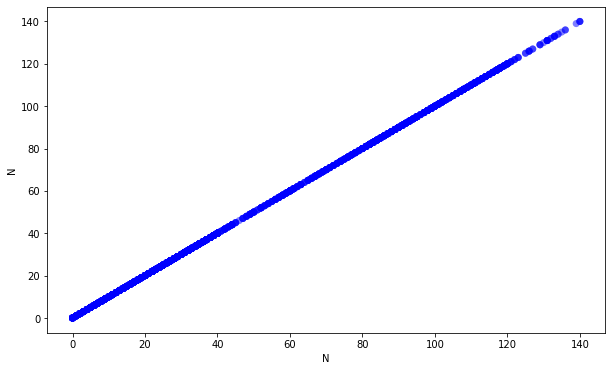

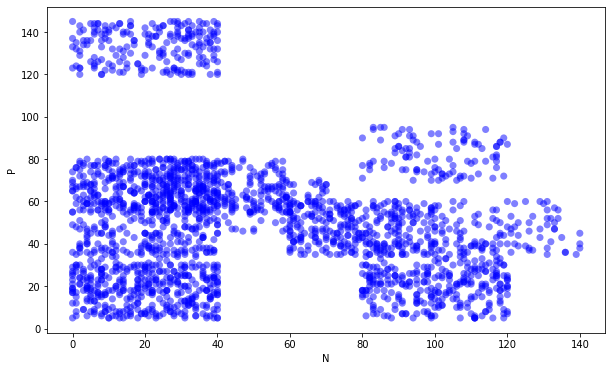

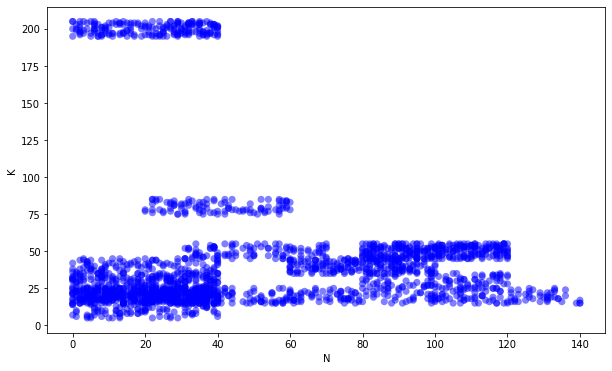

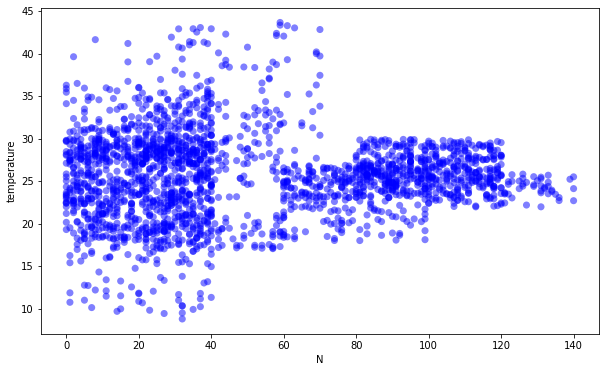

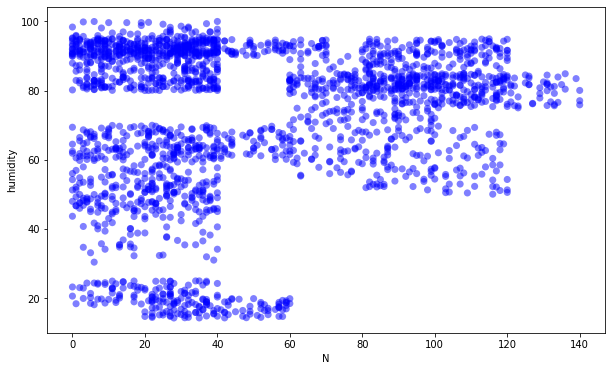

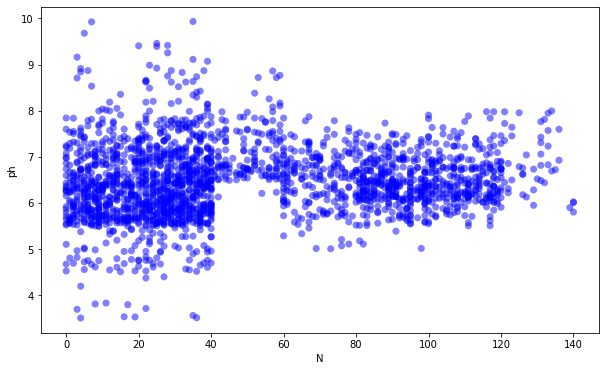

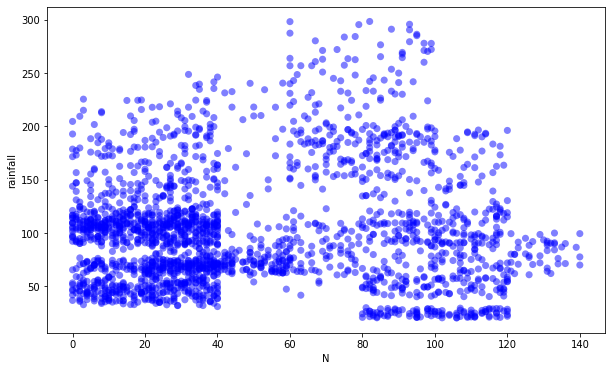

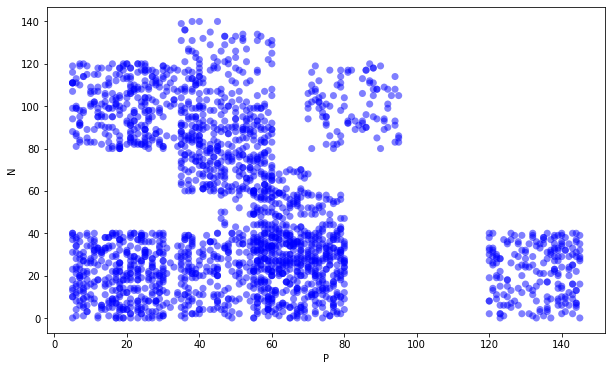

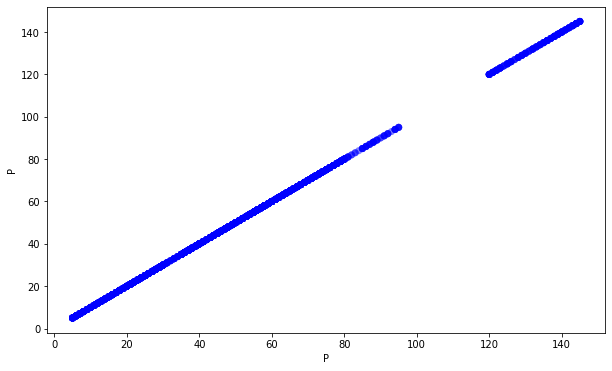

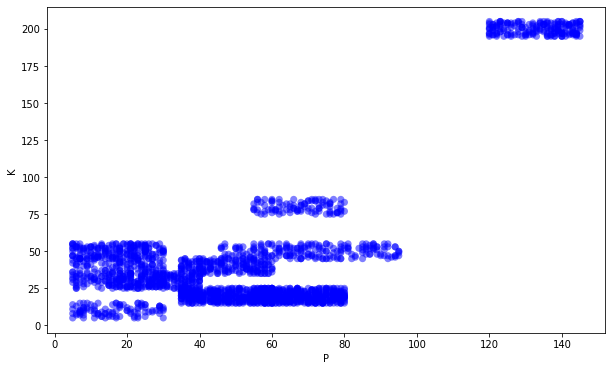

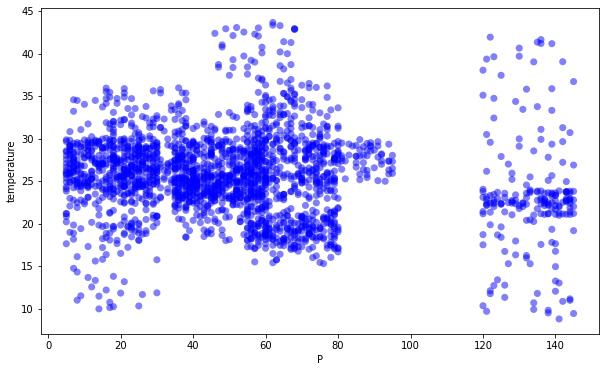

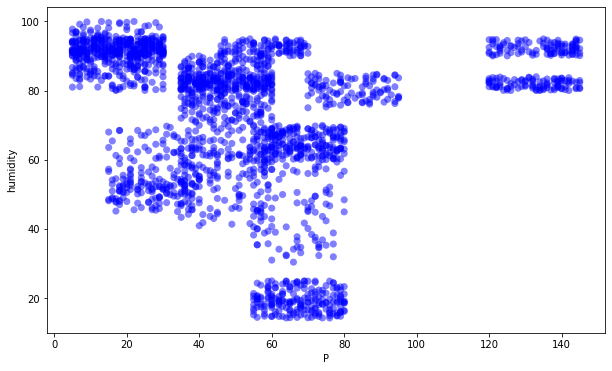

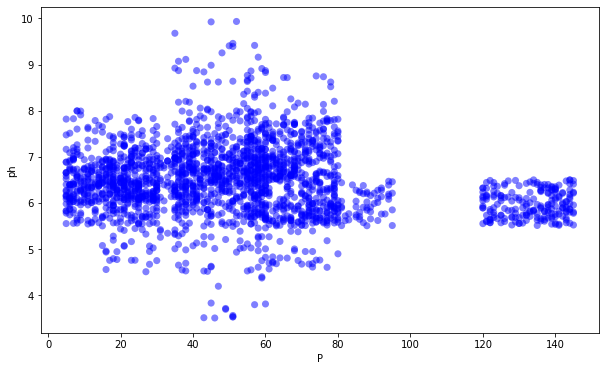

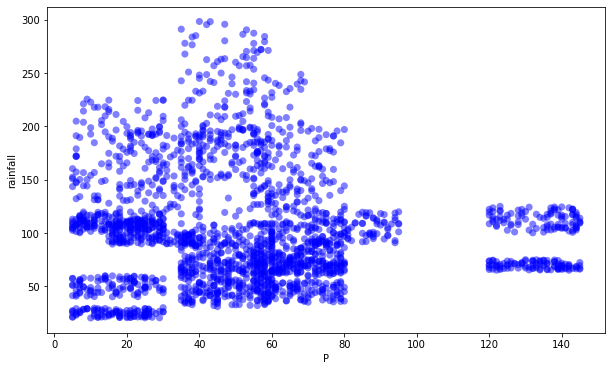

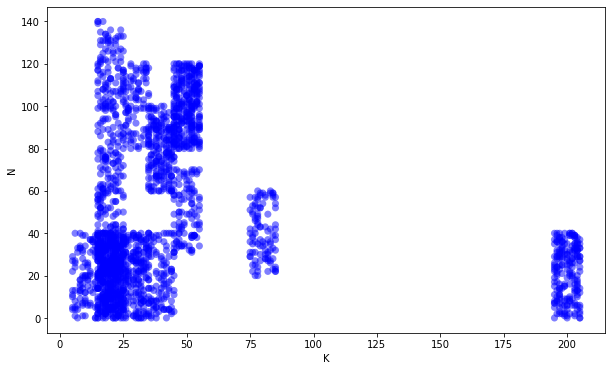

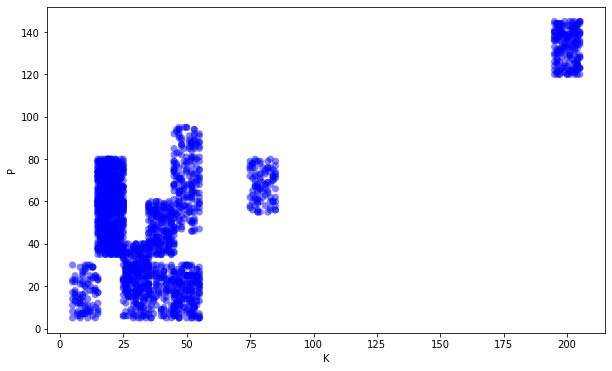

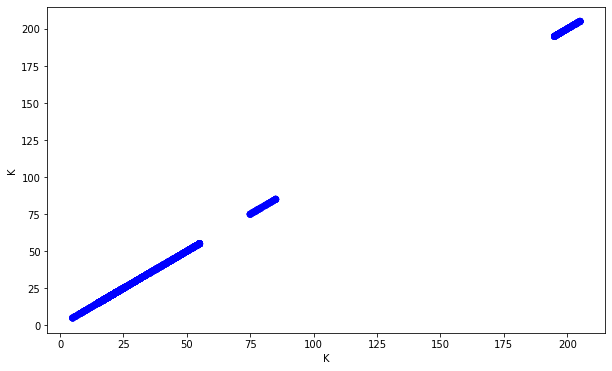

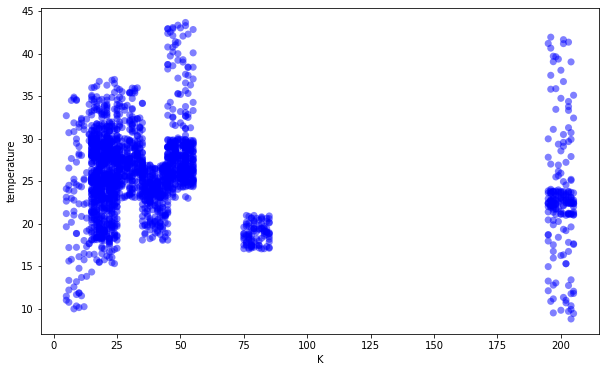

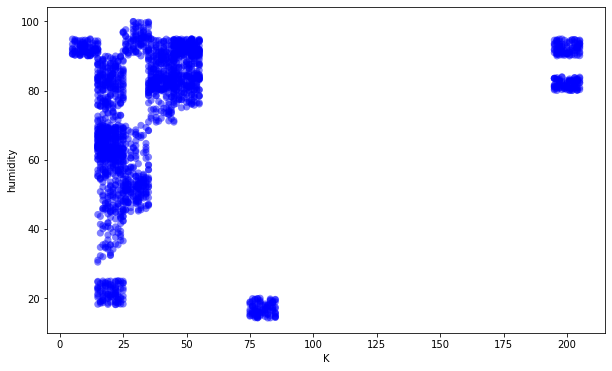

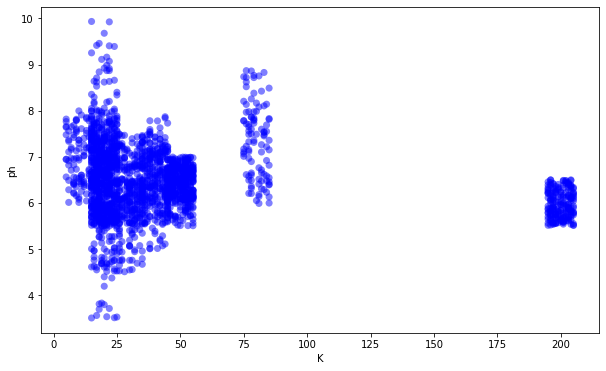

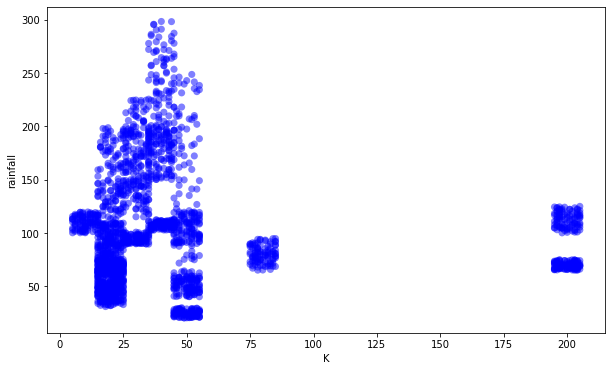

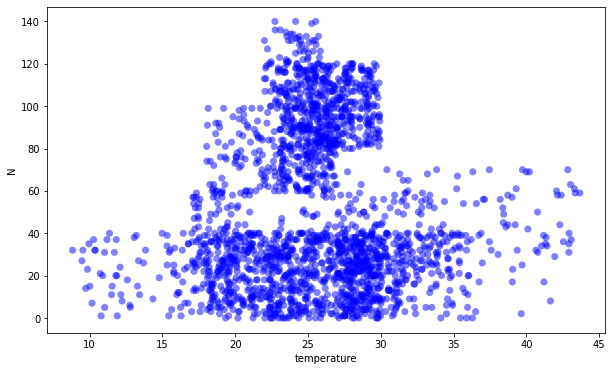

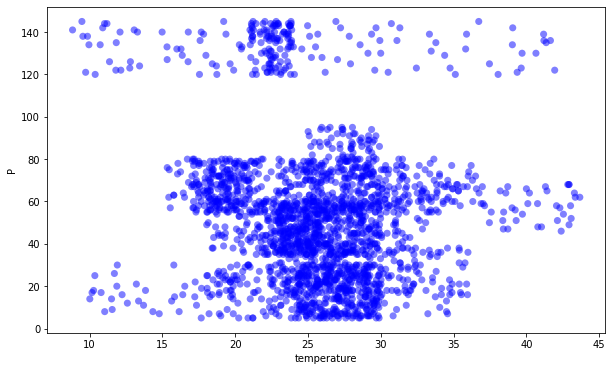

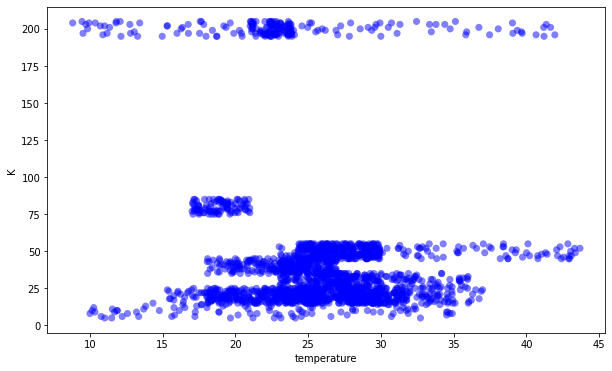

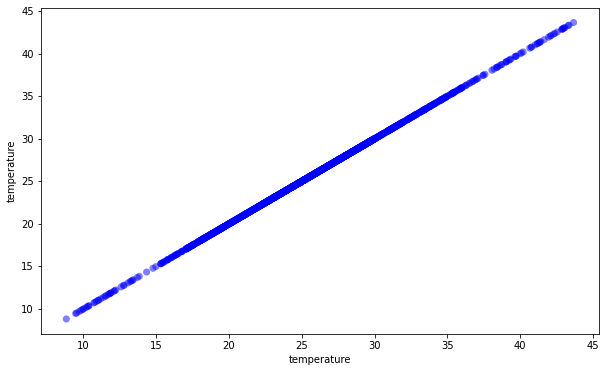

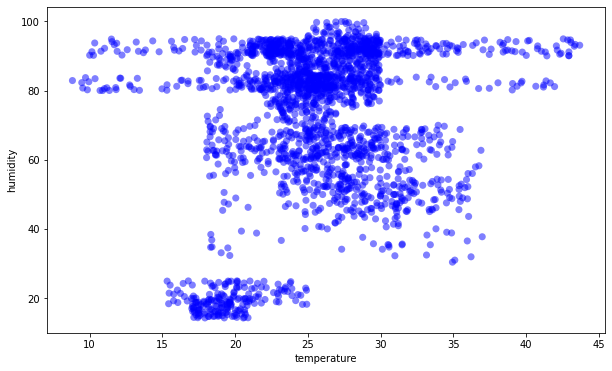

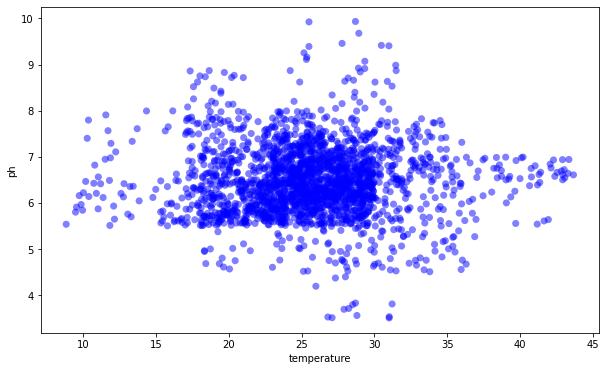

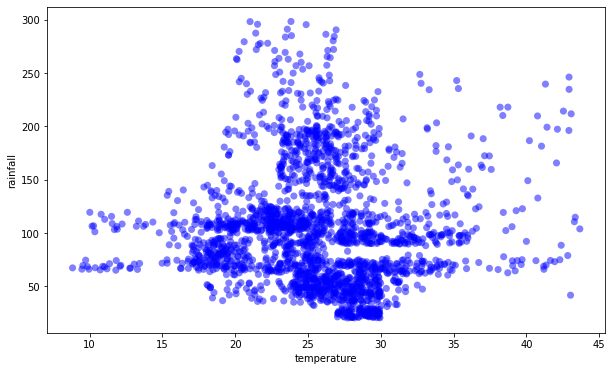

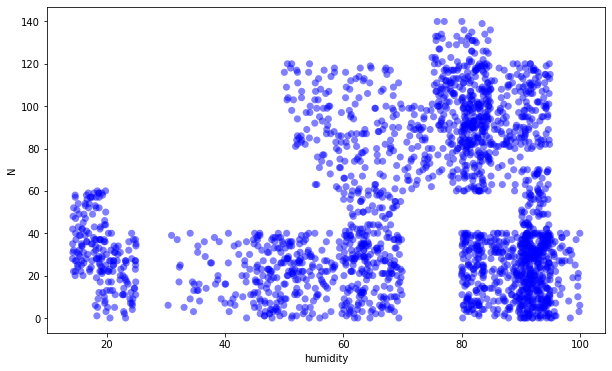

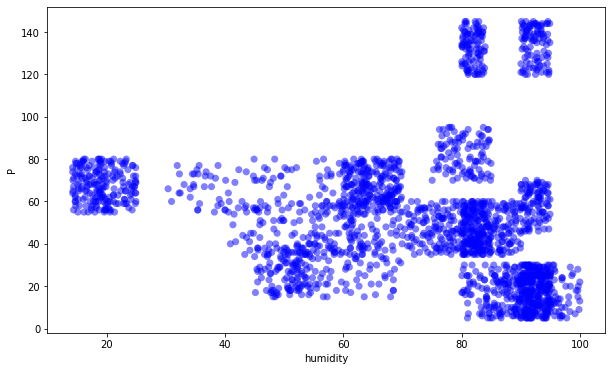

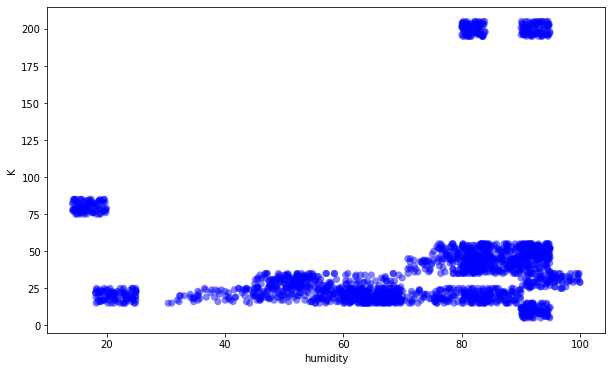

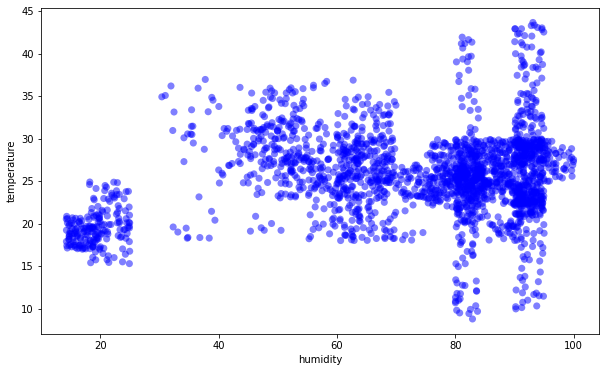

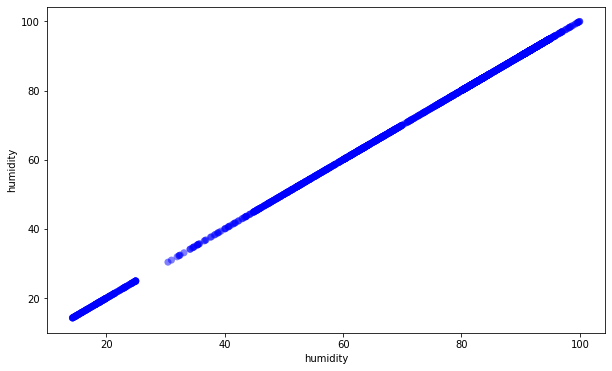

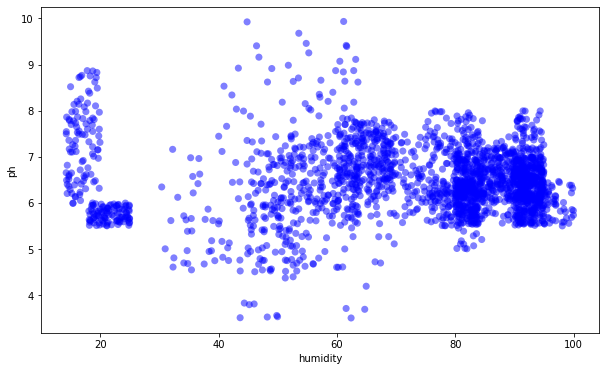

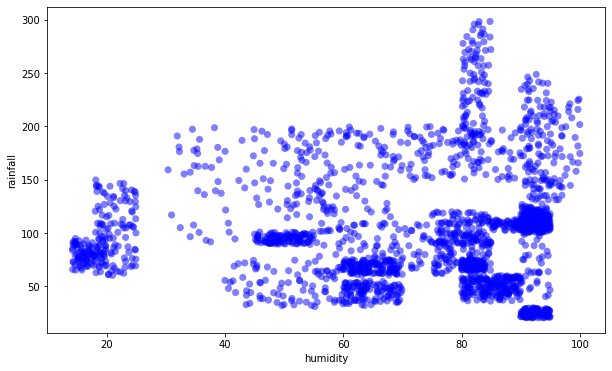

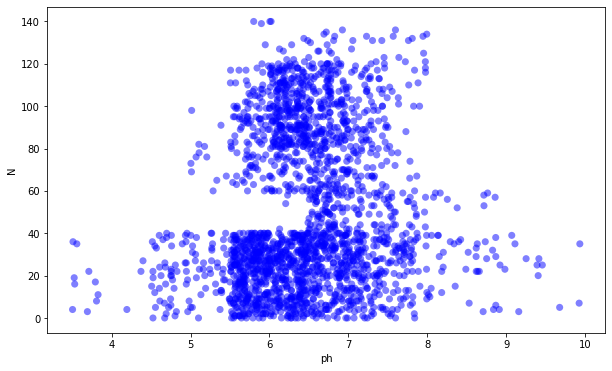

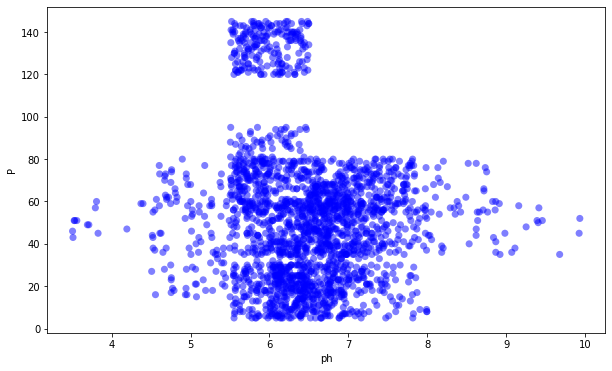

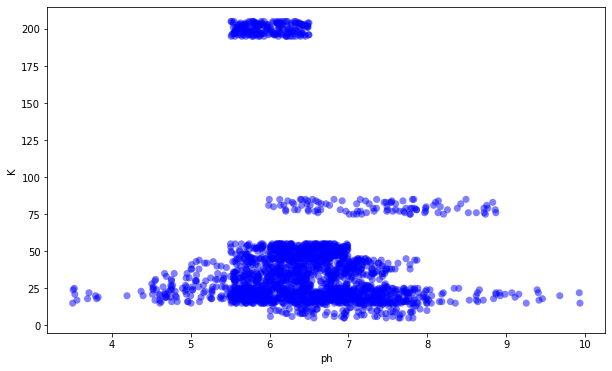

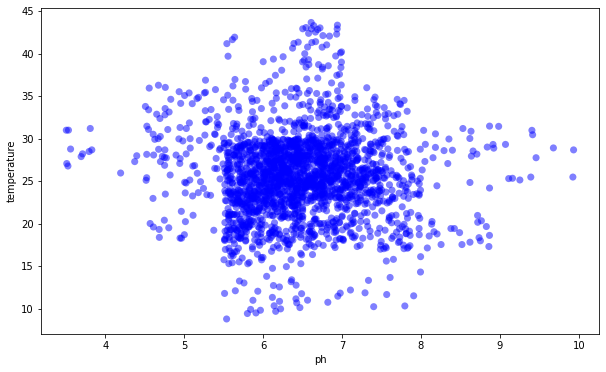

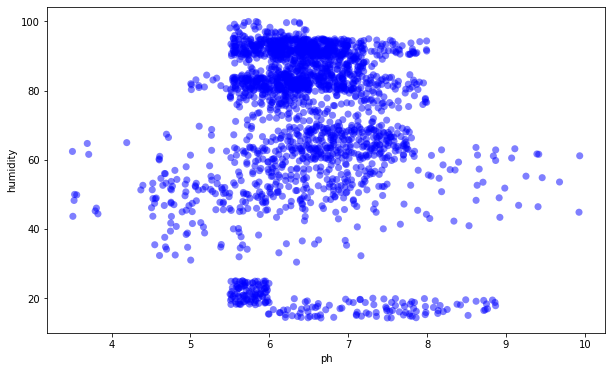

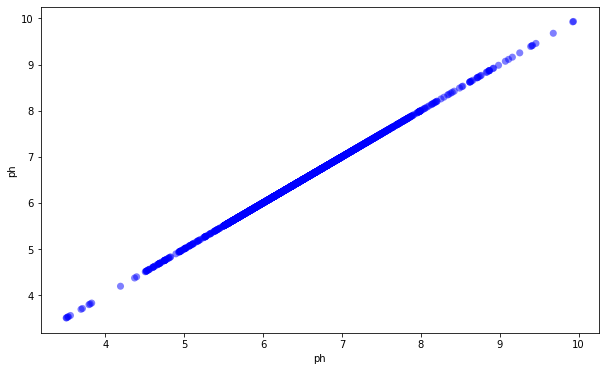

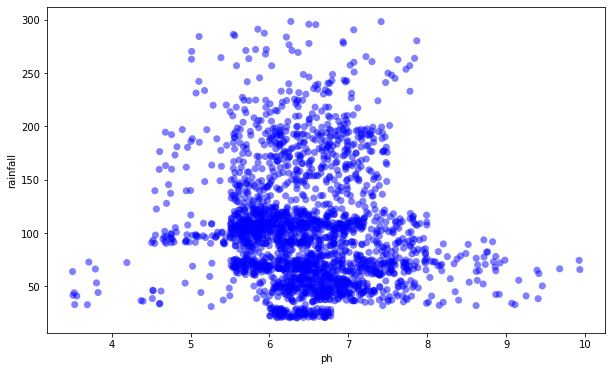

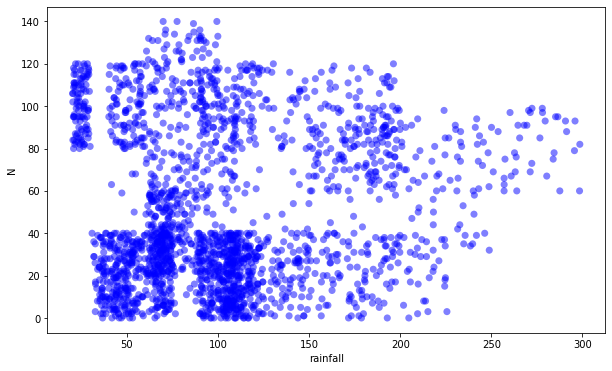

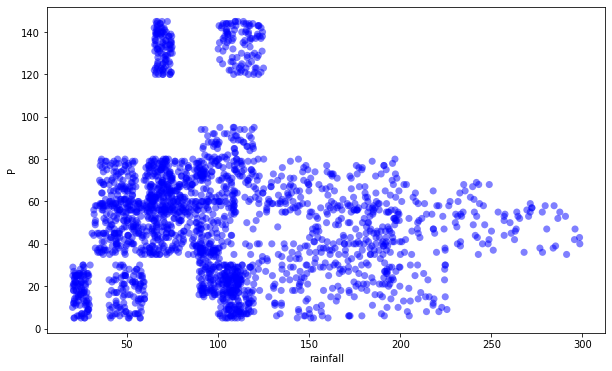

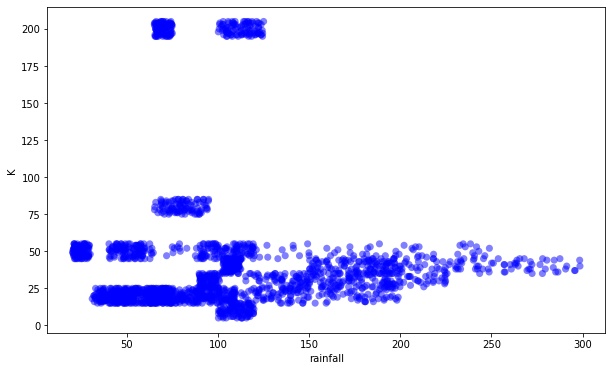

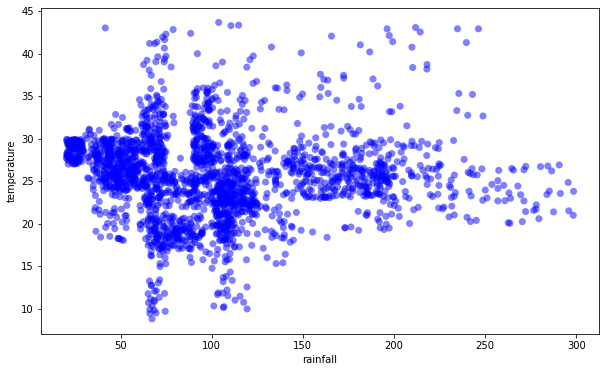

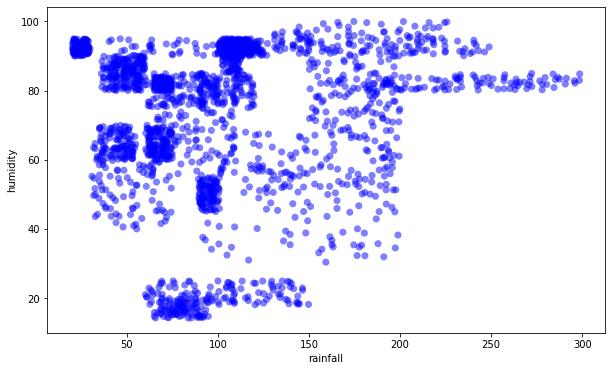

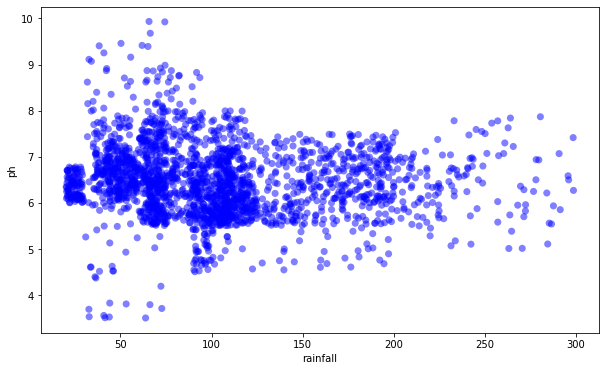

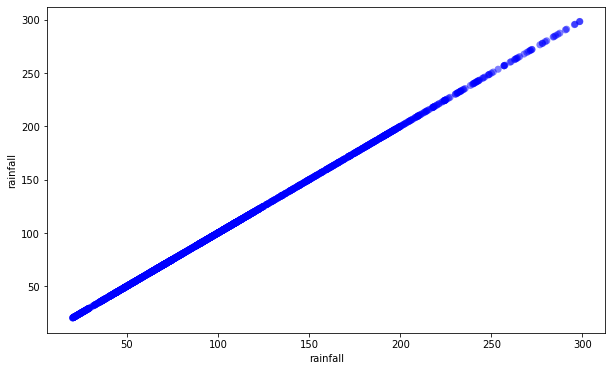

In [19]:
# Plotting Scatterplots of each continuous feature against TARGET_FEATURE
for feature1 in continuous_features:
    for feature2 in continuous_features:
            data=df.copy()
            plt.figure(figsize=(10,6))  # specify figure size
            plt.scatter(df[feature1], df[feature2], s=50, 
                        marker='o',  # use circle markers
                        c='b',       # set marker color to blue
                        alpha=0.5,   # set transparency level
                        edgecolors='none')  # remove marker borders
            plt.xlabel(feature1)
            plt.ylabel(feature2)
            plt.show()

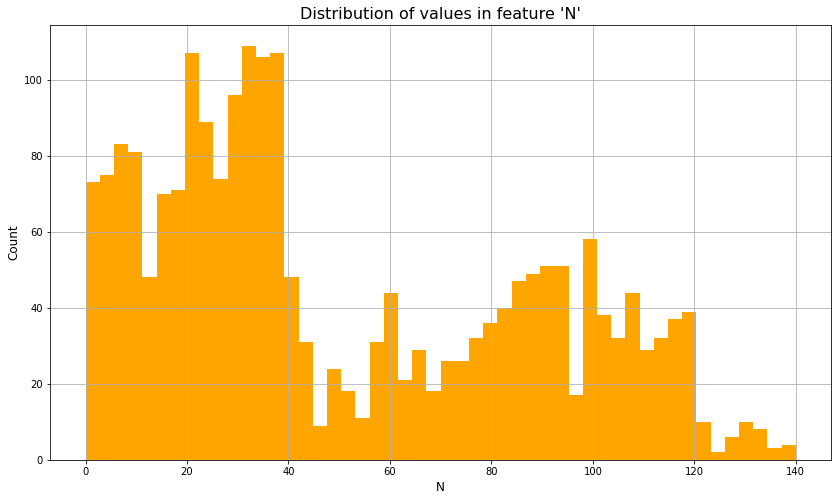

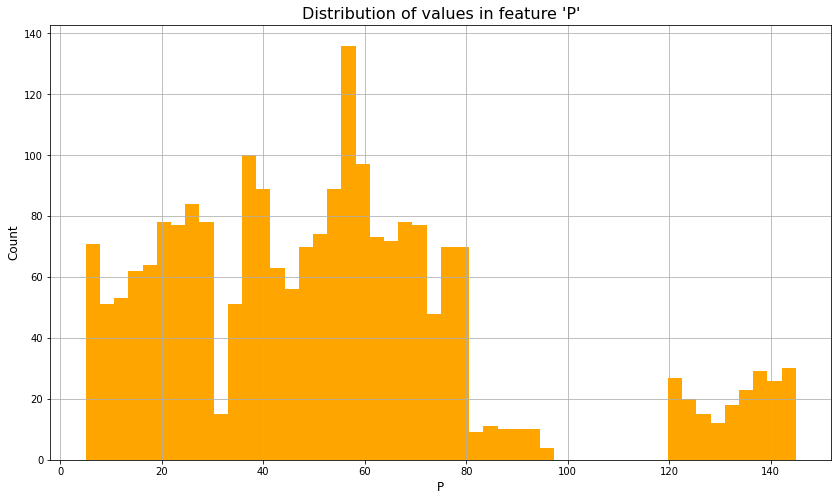

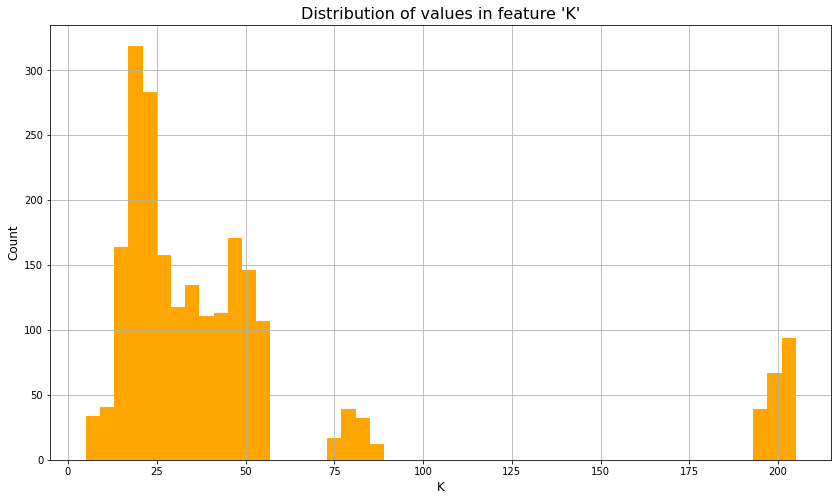

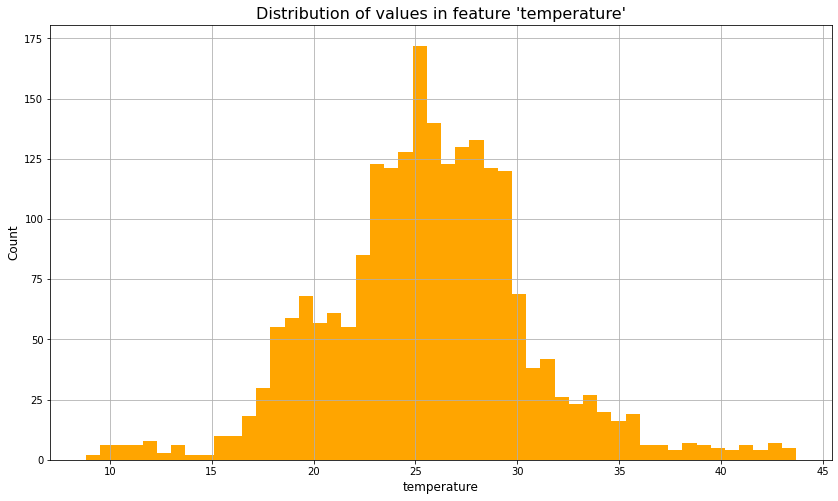

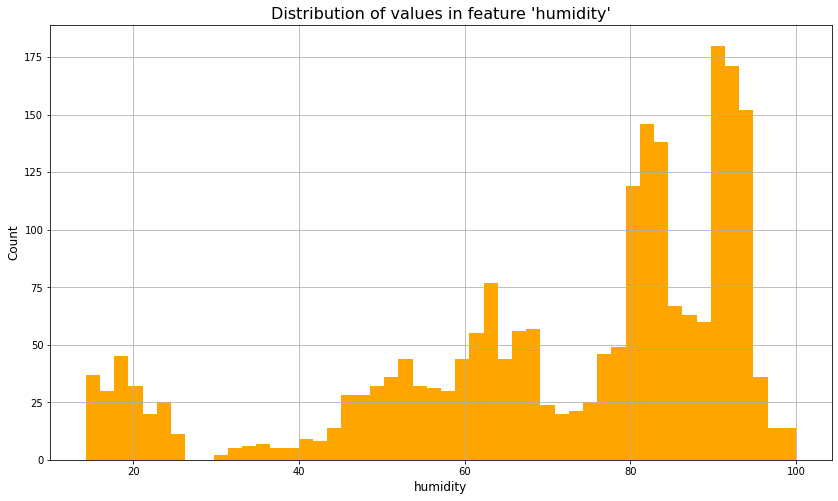

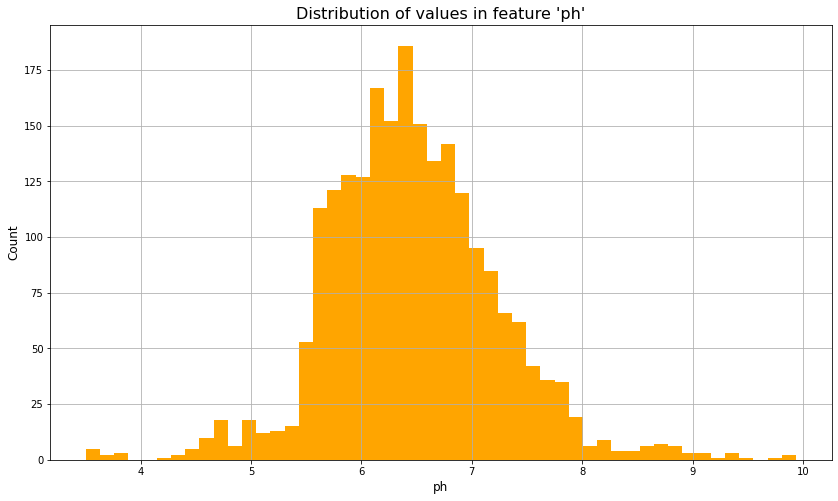

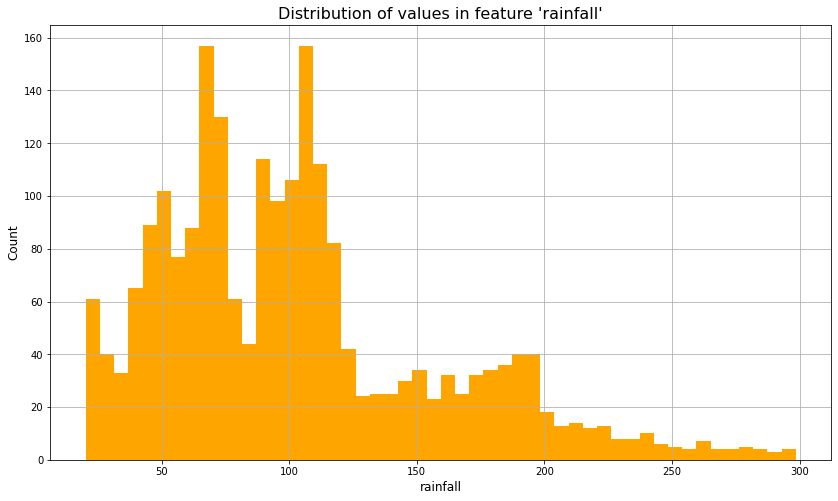

In [21]:
# Find the Distribution of values in each Continuous feature (create histograms)
for feature in continuous_features:
  # Set the figure size
  plt.subplots(figsize=(14, 8))

  # Increase the number of bins
  data[feature].hist(bins=50, color='orange')

  # Add a title
  plt.title("Distribution of values in feature '" + feature + "'", fontsize=16)

  # Adjust the axes labels
  plt.xlabel(feature, fontsize=12)
  plt.ylabel("Count", fontsize=12)

  plt.show()

## **Model Training**

In [189]:
x = df.drop("label", axis=1)
y = df["label"]

print(x.shape)
x.sample(10)

(2200, 7)


,N,P,K,temperature,humidity,ph,rainfall
1647,9,10,10,22.355105,93.522119,6.010392,101.516459
601,8,54,20,28.334043,80.772760,7.034214,38.797641
1745,42,60,47,33.468737,92.127462,6.834808,136.827704
792,29,63,17,30.026299,67.888116,7.261543,66.472646
1456,118,12,47,27.968723,92.174448,6.010740,28.947669
1737,65,62,51,31.532438,90.873949,6.511625,207.073512
625,34,45,21,28.188371,82.606297,6.287380,37.011104
1486,85,21,47,29.873311,90.609325,6.186770,24.697205
1700,61,68,50,35.214628,91.497251,6.793245,243.074507
1409,108,26,52,28.826290,94.267653,6.201798,26.238385


In [190]:
print(y.shape)
y.sample(10)

(2200,)


361     kidneybeans
640        mungbean
1720         papaya
952     pomegranate
923     pomegranate
147           maize
1093         banana
1260         grapes
513       mothbeans
1840        coconut
Name: label, dtype: object

In [263]:
# DATA SPLITTING 
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2,shuffle=True)

## **LightGBM Classifier Model**

In [264]:
# Creating a lightgbm model
import lightgbm as lgb

model = lgb.LGBMClassifier()

# Training the model using Training Data
model.fit(x_train,y_train)

LGBMClassifier()

In [266]:
output = model.predict([[101,10,47,25.5421695,83.31883376,6.936997681,57.57343233]])
print("Predicted Crop : ",output[0])

Predicted Crop :  watermelon


In [267]:
# Save the trained model to a file
model.booster_.save_model('lgbm_model.txt')

### **CONCLUSION : The objective of this notebook have been achieved. We trained and saved our model which we can now use in production environment.**